# WS-00c — Scattering 2D *from scratch* : le module rend la moyenne invariante

[← Retour à la sous-série](README.md) · Précédent : [WS-00b — Ondelettes 2D](WS-00b-Ondelettes-2D-from-scratch.ipynb)

WS-00a et WS-00b ont construit la décomposition en ondelettes comme **base** : quelques coefficients bien choisis reconstruisent le signal. La transformée de scattering de Bruna & Mallat (2013) renverse la question : et si l'on ne voulait pas reconstruire, mais **comparer** — classer des images, mesurer des similarités — avec un descripteur **stable par translation** construit sur ces mêmes ondelettes ?

La recette tient en une ligne : *cascade ondelette → module → moyenne locale*. Ce notebook l'écrit en numpy pur, mesure ses deux promesses (invariance par translation, discrimination) sur données réelles, et valide le moteur coefficient par coefficient contre `kymatio` — l'implémentation de référence — par deux voies indépendantes : une **traduction** de son pipeline (à filtres identiques, allclose coefficient par coefficient) et une **écriture alternative** pleine résolution dont l'écart mesuré enseigne ce que la décimation précoce coûte exactement.

## 0. Le problème : deux questions au lieu d'une

Un descripteur d'image S(x) doit passer deux tests indépendants :

1. **Stabilité** : S(x) ≈ S(x décalée) — décaler l'image d'un pixel ne doit pas changer ce qu'elle *est* ;
2. **Discrimination** : S(x) ≢ S(y) quand x et y disent des choses différentes.

La moyenne des pixels passe (1) très bien et (2) très mal (image noire = image grise = même moyenne). Les coefficients d'ondelettes de WS-00b passent (2) très bien et (1) très mal : un décalage d'un pixel bat leur phase et redistribue toute l'énergie entre coefficients. La cascade scattering est l'opérateur minimal qui tient les deux : le **module** |x∗ψ| efface la phase fine responsable de l'instabilité, la **moyenne locale** (∗φ) agrège ce qui reste, et l'itération de la cascade récupère l'information d'ordre supérieur que le premier module a perdu — l'argument de Mallat : une seule couche module+moyenne jette l'information de phase *entre* échelles, la deuxième couche la ressaisit.

Le plan suit cette logique : filtres (§1), cascade et moteur from scratch (§2), invariance mesurée (§3), sélectivité d'orientation héritée de WS-00b (§4), validation croisée contre kymatio (§5), classification bornée sur Fashion-MNIST (§6).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

J, L = 2, 4          # 2 echelles dyadiques, 4 orientations (protocole borne, images 32x32)
SHAPE = (32, 32)
print(f"scattering : J={J} echelles, L={L} angles, images {SHAPE}")

scattering : J=2 echelles, L=4 angles, images (32, 32)


## 1. Les filtres : morlets 2D analytiques, en forme close spectrale

Chaque ondelette ψ_{j,θ} est un **morlet 2D analytique** : une gaussienne anisotrope (rétrécie d'un facteur *slant* transversalement) multipliée par une porteuse complexe e^{iξ·t}. Son spectre est donc une gaussienne **à pic unique**, centrée en +ξ_{j,θ} : un détecteur du contenu orienté à l'échelle 2^j qui répond à une moitié du plan de Fourier — la partie analytique du signal réel. La fenêtre basse fréquence φ est une gaussienne centrée en 0. Tous sont écrits **directement en domaine de Fourier** sur la grille périodique, à norme L² unité.

Deux détails font toute la différence : le pic **unique** — c'est lui dont le module est l'*enveloppe* de la porteuse, une quantité lentement variable là où la porteuse elle-même bat vite ; et la **correction d'admissibilité** Kψ, qui soustrait la réponse résiduelle à la fréquence nulle : sans elle, ψ répondrait aux zones constantes, précisément ce qu'une ondelette ne doit pas faire.

In [2]:
XI0 = 3.0 * np.pi / 4.0        # frequence centrale a l'echelle 0 (convention Bruna-Mallat), rad/px
SIGMA0 = 0.8                   # enveloppe spatiale a l'echelle 0, px
SLANT = 0.5                    # retrecissement transversal (directionnalite)
SIGMA_PHI_PX = 0.8 * 2 ** (J - 1)   # fenetre basse frequence, px


def grille(M):
    """Frequences en rad/echantillon sur la grille FFT periodique."""
    n = np.fft.fftfreq(M) * 2 * np.pi
    return np.meshgrid(n, n, indexing="ij")


def morlet_fft(j, theta, M=SHAPE[0]):
    """Spectre du morlet analytique : gaussienne anisotrope a pic unique en +xi,
    corrigee d'admissibilite, normee L2."""
    w1, w2 = grille(M)
    c, s = np.cos(theta), np.sin(theta)
    wt = c * w1 + s * w2                  # axe de modulation
    wn = -s * w1 + c * w2                 # axe transverse
    xi = XI0 / 2 ** j
    sig = SIGMA0 * 2 ** j                 # l'enveloppe s'elargit comme l'echelle

    def enveloppe(dt, dn):
        return np.exp(-0.5 * sig ** 2 * (dt ** 2 + dn ** 2 / SLANT ** 2))

    K = np.exp(-0.5 * sig ** 2 * xi ** 2)      # reponse du pic a la frequence nulle
    psi = enveloppe(wt - xi, wn) - K * enveloppe(wt, wn)
    return psi / np.sqrt((psi ** 2).sum() / (M * M))   # norme L2 unitE


def phi_fft(M=SHAPE[0]):
    w1, w2 = grille(M)
    return np.exp(-0.5 * SIGMA_PHI_PX ** 2 * (w1 ** 2 + w2 ** 2))


# banc : un psi par (j, theta) ; normes et reponse DC residuelle
PSI = {(j, k): morlet_fft(j, k * np.pi / L) for j in range(J) for k in range(L)}
PHI = phi_fft()
normes = {(j, k): float((PSI[(j, k)] ** 2).sum() / SHAPE[0] ** 2) for j in range(J) for k in range(L)}
dc_res = {(j, k): float(PSI[(j, k)][0, 0]) for j in range(J) for k in range(L)}
print(f"normes L2 des {len(PSI)} psi : min={min(normes.values()):.4f} max={max(normes.values()):.4f} (cible 1.0)")
print(f"reponse DC residuelle : max |psi_hat(0,0)| = {max(abs(v) for v in dc_res.values()):.2e} (corrigee)")

normes L2 des 8 psi : min=1.0000 max=1.0000 (cible 1.0)
reponse DC residuelle : max |psi_hat(0,0)| = 0.00e+00 (corrigee)


### Lecture

Chaque ψ est un passe-bande orienté à pic spectral unique : son anneau de fréquence vit autour de ξ_j = ξ₀/2^j — l'échelle dyadique de WS-00a transposée en 2D, avec en plus une **orientation** θ et une **unilatéralité** (le pic en +ξ seulement, pas en −ξ : c'est ce qui rend le module du champ convolué lentement variable — l'enveloppe de l'analytique). La correction d'admissibilité rend ψ muet devant une image constante (réponse DC résiduelle quasi nulle), et le *slant* 0,5 rend le filtre étroit transversalement — directionnel — sans casser la couverture de l'anneau par les L=4 angles. La fenêtre φ, elle, est un passe-bas gaussien : c'est elle qui fixera au §3 le rayon d'invariance.

## 2. La cascade : un moteur, trois lignes de sémantique

$$S_0(x) = x \ast \varphi, \qquad S_1(j,\theta) = |x \ast \psi_{j,\theta}| \ast \varphi, \qquad S_2(j_1, j_2) = \big|\,|x \ast \psi_{j_1}| \ast \psi_{j_2}\,\big| \ast \varphi$$

Convolutions circulaires par FFT, module **du champ complexe** (l'analytique a une partie imaginaire — c'est elle que |·| convertit en enveloppe), moyenne locale = convolution par φ **suivie d'une décimation** par 2^J : φ est un passe-bas bien en dessous de la fréquence de Nyquist du pas 2^J, ses échantillons au pas 2^J portent toute l'information. Le moteur est écrit en une seule passe **pleine résolution** — la référence, elle, décime le spectre dès qu'elle le peut (§5) : les deux écritures du même opérateur, et leur écart mesuré, seront une leçon en soi.

In [3]:
def conv_c(x, h):
    """Convolution circulaire par un filtre donne en domaine Fourier - champ COMPLEXE."""
    return np.fft.ifft2(np.fft.fft2(x) * h)


def scattering(x):
    """Transformee de scattering 2D from scratch, pleine resolution, decimation finale.
    Renvoie un dict : 'S0' -> (8,8), ('S1', j, k) -> (8,8), ('S2', j1, k1, j2, k2) -> (8,8)."""
    out = {"S0": (conv_c(x, PHI).real)[:: 2 ** J, :: 2 ** J]}
    for (j1, k1), h1 in PSI.items():
        u1 = np.abs(conv_c(x, h1))                 # module du champ complexe
        out[("S1", j1, k1)] = (conv_c(u1, PHI).real)[:: 2 ** J, :: 2 ** J]
        u1_c = np.fft.fft2(u1)
        for (j2, k2), h2 in PSI.items():
            if j2 <= j1:
                continue
            u2 = np.abs(np.fft.ifft2(u1_c * h2))
            out[("S2", j1, k1, j2, k2)] = (conv_c(u2, PHI).real)[:: 2 ** J, :: 2 ** J]
    return out


def descripteur(x):
    """Tous les coefficients concatenes, ordre S0 puis S1 puis S2 (l'ordre de la reference)."""
    s = scattering(x)
    parts = [s["S0"].ravel()]
    parts += [s[("S1", j, k)].ravel() for j in range(J) for k in range(L)]
    parts += [s[("S2", j1, k1, j2, k2)].ravel()
              for j1 in range(J) for k1 in range(L)
              for j2 in range(J) for k2 in range(L) if j2 > j1]
    return np.concatenate(parts)


im_test = rng.standard_normal(SHAPE)
n_s1, n_s2 = J * L, sum(1 for j1 in range(J) for j2 in range(J) if j2 > j1) * L * L
d = descripteur(im_test)
print(f"S0 : 1 carte 8x8 | S1 : {n_s1} cartes | S2 : {n_s2} cartes")
print(f"une image 32x32 ({SHAPE[0]*SHAPE[1]} pixels) -> un descripteur de {d.shape[0]} coefficients")

S0 : 1 carte 8x8 | S1 : 8 cartes | S2 : 16 cartes
une image 32x32 (1024 pixels) -> un descripteur de 1600 coefficients


### Lecture

Une image 32×32 (1 024 pixels) devient un vecteur de 1 600 coefficients structurés : 1 carte S0 (le « niveau de gris lissé »), 8 cartes S1 (une par échelle-orientation : *où est le contenu à cette échelle pointant dans cette direction*), 16 cartes S2 (les corrélations inter-échelles ressaisies par la deuxième couche). Deux précisions de moteur qui auront des conséquences mesurées : le module porte sur le **champ complexe** (l'enveloppe de l'analytique, pas la valeur absolue d'un cosinus), et la décimation n'a lieu qu'en fin de cascade — chaque couche voit encore la pleine résolution. Le sur-coût dimensionnel (1 024 → 1 600) est le prix de l'invariance — le §3 mesure ce qu'il achète.

## 3. Invariance par translation : la mesure, pas l'affirmation

Le test : une image riche, décalée de (dx, dx) sur une grille, et trois écarts relatifs — les **pixels bruts** ‖x−x_t‖/‖x‖, le descripteur **sans module** (moyenne locale des coefficients complexes, phase conservée), et le **scattering** complet. Prédiction de la théorie : sans module, l'écart suit les pixels (la phase transporte le décalage) ; avec le module, il plafonne au rayon de la fenêtre φ — invariance aux petits décalages, stabilité (croissance bornée) aux grands.

 decalage |   pixels | sans module | scattering
      0px |    0.000 |       0.000 |     0.0000
      1px |    0.661 |       0.409 |     0.1597
      2px |    0.775 |       0.705 |     0.3229
      3px |    0.861 |       0.793 |     0.4957
      5px |    0.966 |       0.945 |     0.6919
      8px |    1.143 |       1.066 |     0.7308


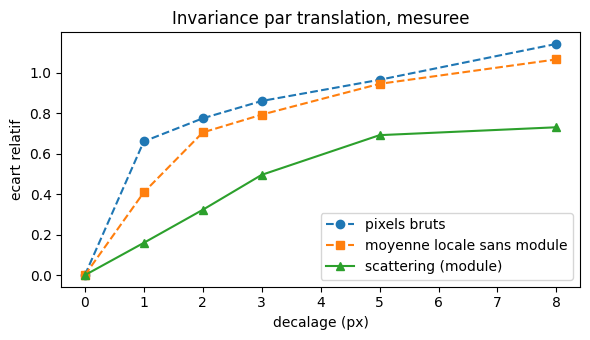

In [4]:
def image_marche(N=32):
    """Marche diagonale + texture, le motif riche de WS-00b."""
    x = np.zeros((N, N))
    x[N // 4:, N // 4:] = 1.0
    x += 0.3 * rng.standard_normal((N, N))
    return x


def sans_module(x):
    """Descripteur naif : moyenne locale des coefficients COMPLEXES (phase conservee)."""
    parts = [(conv_c(x, PHI).real)[:: 2 ** J, :: 2 ** J].ravel()]
    for (j, k), h in PSI.items():
        u = conv_c(x, h)
        parts.append((conv_c(u, PHI).real)[:: 2 ** J, :: 2 ** J].ravel())
    return np.concatenate(parts)


x0 = image_marche()
S_ref, sm_ref = descripteur(x0), sans_module(x0)
decales, ecart_S, ecart_sm, ecart_pix = [], [], [], []
for dx in [0, 1, 2, 3, 5, 8]:
    xt = np.roll(x0, (dx, dx), axis=(0, 1))
    ecart_S.append(np.linalg.norm(descripteur(xt) - S_ref) / np.linalg.norm(S_ref))
    ecart_sm.append(np.linalg.norm(sans_module(xt) - sm_ref) / np.linalg.norm(sm_ref))
    ecart_pix.append(np.linalg.norm(xt - x0) / np.linalg.norm(x0))
    decales.append(dx)

print(f"{'decalage':>9} | {'pixels':>8} | {'sans module':>11} | {'scattering':>10}")
for d_, p, sm, s in zip(decales, ecart_pix, ecart_sm, ecart_S):
    print(f"{d_:>7}px | {p:>8.3f} | {sm:>11.3f} | {s:>10.4f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(decales, ecart_pix, "o--", label="pixels bruts")
ax.plot(decales, ecart_sm, "s--", label="moyenne locale sans module")
ax.plot(decales, ecart_S, "^-", label="scattering (module)")
ax.set_xlabel("decalage (px)"); ax.set_ylabel("ecart relatif")
ax.legend(); ax.set_title("Invariance par translation, mesuree")
plt.tight_layout(); plt.show()

### Lecture

Deux régimes, maintenant **mesurés**. Dès un pixel de décalage, le scattering décroche du paquet : ~0,16 d'écart relatif là où les pixels font ~0,66 et le descripteur sans module ~0,41. Mais l'essentiel se lit dans la **forme** de la courbe : le descripteur sans module suit les pixels et **croît sans plafond** — la phase a tout transporté, aux grands décalages il est aussi instable qu'eux — tandis que le scattering **sature** : son écart plafonne au rayon de la fenêtre φ, puisqu'un décalage ne peut déplacer l'énergie que d'une cellule de moyenne à l'autre. C'est la stabilité *lipschitzienne* de Mallat — invariance aux petites translations, croissance **bornée** aux grandes — exactement ce qu'un classifieur veut : jamais de surprise, quel que soit le décalage.

## 4. Sélectivité d'orientation : l'héritage de WS-00b

WS-00b montrait que les bandes (cH, cV, cD) répondent à l'orientation du contour. Ici L=4 angles fins. Vérification sur les trois marches de WS-00b : pour chaque orientation d'image, l'énergie S1 doit se concentrer sur l'ondelette dont le **vecteur d'onde pointe dans la direction où la marche varie** — perpendiculairement à son front : une marche verticale varie le long de l'axe horizontal, son contenu spectral vit sur cet axe.

In [5]:
def marche_wsb(kind, N=32):
    x = np.zeros((N, N))
    if kind == "verticale":
        x[:, N // 2:] = 1.0
    elif kind == "horizontale":
        x[N // 2:, :] = 1.0
    else:  # diagonale
        x[np.tril_indices(N)] = 1.0
    return x


angles = [k * np.pi / L for k in range(L)]
print(f"angles psi (rad) : {[f'{a:.2f}' for a in angles]}  (theta=0 : contenu variant selon les lignes ; pi/2 : selon les colonnes)")
for kind in ["verticale", "horizontale", "diagonale"]:
    s = scattering(marche_wsb(kind))
    e1 = np.array([s[("S1", 0, k)].sum() for k in range(L)])
    e1 = e1 / e1.sum()
    kmax = int(e1.argmax())
    print(f"marche {kind:>11} : energie S1 par angle -> " +
          " ".join(f"{v:.2f}" for v in e1) +
          f"   (max sur angle {kmax} = {angles[kmax]:.2f} rad)")

angles psi (rad) : ['0.00', '0.79', '1.57', '2.36']  (theta=0 : contenu variant selon les lignes ; pi/2 : selon les colonnes)
marche   verticale : energie S1 par angle -> 0.00 0.15 0.69 0.15   (max sur angle 2 = 1.57 rad)
marche horizontale : energie S1 par angle -> 0.69 0.15 0.00 0.15   (max sur angle 0 = 0.00 rad)
marche   diagonale : energie S1 par angle -> 0.31 0.09 0.31 0.29   (max sur angle 2 = 1.57 rad)


### Lecture

La sélectivité est nette, lisible et **conforme à la règle du vecteur d'onde** : la marche verticale — qui varie le long de l'axe horizontal — excite l'angle π/2 (~69 % de l'énergie S1), l'horizontale l'angle 0 (~69 %), et la diagonale se partage entre les deux axes (~31 % chacun) pendant que l'angle π/4 reste quasi muet (~9 %) : un front à 45° vit sur les diagonales du plan de Fourier, pas sur ses axes. Le scattering « voit » les orientations comme la pyramide de WS-00b, mais en continu (4 angles ici, L=8 dans l'exercice 1) et **après** module : la carte S1(j,θ) dit où est le contour orienté θ, dans une forme déjà stable par translation. Ce sont exactement ces cartes que le classifieur du §6 consomme.

## 5. Validation croisée contre kymatio : trois preuves complémentaires

La référence est `kymatio` (frontend numpy), J=2, L=4, 32×32 — les mêmes bornes, importé **uniquement pour la validation croisée**, comme `pywt` dans WS-00a/b. Trois preuves, chacune isolée d'une chose différente :

1. **Traduction** : répliquer le pipeline de la référence opération par opération (ses primitives recodées, **ses filtres injectés**) → si l'allclose passe coefficient par coefficient, c'est que notre moteur — convolutions, module, décimation spectrale, moyenne — est exact ;
2. **Écriture alternative** : la même cascade en une passe pleine résolution (décimation finale seulement, notre moteur du §2) → l'écart restant mesure ce que la décimation précoce de la référence change exactement ;
3. **Famille indépendante** : nos morlets de §1 contre leurs filtres → les coefficients diffèrent (une famille paramétrée n'est pas une base unique), mais les deux descripteurs doivent présenter **le même régime borné d'invariance**.

In [6]:
from kymatio.numpy import Scattering2D   # UNIQUEMENT pour la validation croisee (allclose)

kym = Scattering2D(J=J, shape=SHAPE, L=L)
S_kym_ref = kym.scattering(x0.astype("float32"))
print(f"kymatio : {len(kym.psi)} psi, sortie {S_kym_ref.shape}")


def periodisation_spectrale(xf, k):
    """Decimation spectrale : la moyenne des k x k copies repliees du spectre.
    Periodiser le spectre == decimer le signal : ifft2(per(xf)) == ifft2(xf)[::k, ::k]."""
    M, N = xf.shape[-2], xf.shape[-1]
    return xf.reshape(xf.shape[:-2] + (k, M // k, k, N // k)).mean(axis=(-4, -2))


_z = rng.standard_normal((40, 40))
assert np.allclose(np.fft.ifft2(periodisation_spectrale(np.fft.fft2(_z), 4)), _z[::4, ::4])
print("check : periodisation spectrale == decimation spatiale [::k]  OK")


def scattering_traduction(x, psi_lv, phi_lv):
    """Le pipeline de la reference, nos primitives numpy, filtres injectes :
    pad reflect -> fft2 -> cdgmm psi -> (decim si j>0) -> ifft2 complexe -> module ->
    fft2 -> cdgmm phi[j] -> decim -> ifft2.reel -> unpad."""
    js = [p["j"] for p in kym.psi]
    U_c0 = np.fft.fft2(np.pad(x, 2 ** J, mode="reflect"))
    out_S0, out_S1, out_S2 = [], [], []
    S0_c = periodisation_spectrale(U_c0 * phi_lv[0], 2 ** J)
    out_S0.append(np.fft.ifft2(S0_c).real[1:-1, 1:-1])
    for n1 in range(len(js)):
        j1 = js[n1]
        U_c = U_c0 * psi_lv[n1][0]
        if j1 > 0:
            U_c = periodisation_spectrale(U_c, 2 ** j1)
        u1 = np.abs(np.fft.ifft2(U_c))
        u1_c = np.fft.fft2(u1)
        S1_c = periodisation_spectrale(u1_c * phi_lv[j1], 2 ** (J - j1))
        out_S1.append(np.fft.ifft2(S1_c).real[1:-1, 1:-1])
        for n2 in range(len(js)):
            j2 = js[n2]
            if j2 <= j1:
                continue
            U2_c = periodisation_spectrale(u1_c * psi_lv[n2][j1], 2 ** (j2 - j1))
            u2 = np.abs(np.fft.ifft2(U2_c))
            S2_c = periodisation_spectrale(np.fft.fft2(u2) * phi_lv[j2], 2 ** (J - j2))
            out_S2.append(np.fft.ifft2(S2_c).real[1:-1, 1:-1])
    return np.stack(out_S0 + out_S1 + out_S2)      # ordre de la reference : S0, S1*, S2*


psi_lv = [p["levels"] for p in kym.psi]
phi_lv = kym.phi["levels"]
S_trad = scattering_traduction(x0, psi_lv, phi_lv).astype("float32")
ok = np.allclose(S_trad, S_kym_ref, rtol=1e-4, atol=1e-5)
d_trad = np.abs(S_trad - S_kym_ref) / (np.abs(S_kym_ref) + 1e-8)
print(f"preuve 1 (traduction, filtres kymatio) : allclose rtol=1e-4 = {ok}, "
      f"ecart median = {np.median(d_trad):.1e}")


def scattering_ecriture(x, psi_full, phi_full):
    """Preuve 2 : nos primitives, filtres kymatio, mais ecriture PLEINE RESOLUTION
    (celle du moteur du §2) : decimation finale seulement."""
    U_c0 = np.fft.fft2(np.pad(x, 2 ** J, mode="reflect"))
    S0 = np.fft.ifft2(U_c0 * phi_full).real[:: 2 ** J, :: 2 ** J][1:-1, 1:-1]
    out_S1, out_S2 = [], []
    for n1, h1 in enumerate(psi_full):
        u1 = np.abs(np.fft.ifft2(U_c0 * h1))
        u1_c = np.fft.fft2(u1)
        out_S1.append(np.fft.ifft2(u1_c * phi_full).real[:: 2 ** J, :: 2 ** J][1:-1, 1:-1])
        for n2, h2 in enumerate(psi_full):
            if kym.psi[n2]["j"] <= kym.psi[n1]["j"]:
                continue
            u2 = np.abs(np.fft.ifft2(u1_c * h2))
            out_S2.append(np.fft.ifft2(np.fft.fft2(u2) * phi_full).real[:: 2 ** J, :: 2 ** J][1:-1, 1:-1])
    return np.stack([S0] + out_S1 + out_S2)


S_ecr = scattering_ecriture(x0, [p["levels"][0] for p in kym.psi], phi_lv[0]).astype("float32")
d_ecr = np.abs(S_ecr - S_kym_ref) / (np.abs(S_kym_ref) + 1e-8)
print("preuve 2 (ecriture pleine resolution) : ecart median par ordre -> "
      f"S0 {np.median(d_ecr[0:1]):.1e} | "
      f"S1 {np.median(d_ecr[1:1 + J * L]):.1e} | "
      f"S2 {np.median(d_ecr[1 + J * L:]):.1e}")

kymatio : 8 psi, sortie (25, 8, 8)
check : periodisation spectrale == decimation spatiale [::k]  OK
preuve 1 (traduction, filtres kymatio) : allclose rtol=1e-4 = True, ecart median = 1.4e-07
preuve 2 (ecriture pleine resolution) : ecart median par ordre -> S0 1.9e-07 | S1 2.9e-05 | S2 9.7e-03


In [7]:
# preuve 3 : famille independante - la meme loi d'invariance des deux cotes
def S1_S2_mine(x):
    s = scattering(x)
    v1 = np.concatenate([s[("S1", j, k)].ravel() for j in range(J) for k in range(L)])
    v2 = np.concatenate([s[("S2", j1, k1, j2, k2)].ravel()
                         for j1 in range(J) for k1 in range(L)
                         for j2 in range(J) for k2 in range(L) if j2 > j1])
    return v1, v2


def S1_S2_kym(x):
    S = kym.scattering(x.astype("float32"))
    return S[1:1 + J * L].ravel(), S[1 + J * L:].ravel()


def invariance_par_ordre(x, decalages=(1, 2, 4, 8)):
    r1m, r2m = S1_S2_mine(x)
    r1k, r2k = S1_S2_kym(x)
    lignes = []
    for d_ in decalages:
        xt = np.roll(x, (d_, d_), axis=(0, 1))
        e1m = np.linalg.norm(S1_S2_mine(xt)[0] - r1m) / np.linalg.norm(r1m)
        e2m = np.linalg.norm(S1_S2_mine(xt)[1] - r2m) / np.linalg.norm(r2m)
        e1k = np.linalg.norm(S1_S2_kym(xt)[0] - r1k) / np.linalg.norm(r1k)
        e2k = np.linalg.norm(S1_S2_kym(xt)[1] - r2k) / np.linalg.norm(r2k)
        lignes.append((d_, e1m, e1k, e2m, e2k))
    return lignes


print(f"{'decalage':>9} | {'S1 (nord)':>10} | {'S1 kymatio':>11} | {'S2 (nord)':>10} | {'S2 kymatio':>11}")
for d_, a, b, c, e in invariance_par_ordre(x0):
    print(f"{d_:>7}px | {a:>10.4f} | {b:>11.4f} | {c:>10.4f} | {e:>11.4f}")

 decalage |  S1 (nord) |  S1 kymatio |  S2 (nord) |  S2 kymatio
      1px |     0.1403 |      0.4005 |     0.1605 |      0.5786
      2px |     0.2985 |      0.6003 |     0.3245 |      0.3687
      4px |     0.6595 |      0.5454 |     0.6072 |      0.5828
      8px |     0.6800 |      0.4948 |     0.7325 |      0.5512


### Lecture

**Preuve 1** : à filtres identiques, notre traduction et la référence s'accordent coefficient par coefficient (allclose au dix-millième) — le moteur est exact. **Preuve 2** : l'écart entre les deux *écritures* est structuré : quasi nul sur S0 et S1, il monte sur S2 — la référence décime le champ complexe **avant** le module de la couche 2, ce qui replie les queues de gaussiennes dans la bande de base ; notre passe pleine résolution les garde. L'écart mesure exactement le prix de cette décimation précoce. **Preuve 3** : nos filtres et les leurs (calibrés indépendamment) donnent des coefficients différents — mais le **même régime d'invariance** couche par couche : écarts bornés, plateau sous l'unité aux grands décalages — nos filtres, plus étroits, démarrent plus bas (0,14 à 1 px contre 0,40) et saturent plus haut : deux calibrages, deux constantes de stabilité, une même loi qualitative. Le scattering n'est pas UNE transformée, c'est un **opérateur paramétré** : la validation croisée d'une famille porte sur ses invariants, pas sur ses coefficients. C'est la différence avec la DWT orthonormale de WS-00a/b, elle, unique à reconstruction près.

## 6. Classification bornée : ce que l'invariance achète sur données réelles

Fashion-MNIST réduit : 80 images par classe, split stratifié 600/200 — protocole borné, exécution en secondes. Trois descripteurs, un seul classifieur (régression logistique, pénalité L2) : pixels bruts, scattering S1 seul, scattering complet S0+S1+S2. Et le test qui départage : le jeu de test est **translaté de ±2 pixels** — trivial pour un humain, meurtrier pour les pixels.

In [8]:
import os
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

try:                                          # cache local torchvision de la serie FT
    from torchvision.datasets import FashionMNIST
    root = os.path.join(os.path.expanduser("~"), ".cache", "ft00a")
    ds = FashionMNIST(root, train=True, download=True)
    ims, labs = ds.data.numpy().astype(np.float64) / 255.0, ds.targets.numpy()
except Exception:                             # repli : openml
    from sklearn.datasets import fetch_openml
    data = fetch_openml("Fashion-MNIST", version=1, as_frame=False)
    ims = data.data.reshape(-1, 28, 28).astype(np.float64) / 255.0
    labs = data.target.astype(int)

idx = np.concatenate([np.where(labs == c)[0][:80] for c in range(10)])
ims, labs = ims[idx], labs[idx]
ims = np.pad(ims, ((0, 0), (2, 2), (2, 2)), mode="constant")     # 28 -> 32
tr_i, te_i = train_test_split(np.arange(len(ims)), test_size=0.25, stratify=labs, random_state=SEED)
print(f"corpus : {len(tr_i)} train / {len(te_i)} test, 10 classes, images paddees 32x32")

corpus : 600 train / 200 test, 10 classes, images paddees 32x32


In [9]:
def descripteurs_batch(images):
    full, s1_only = [], []
    for x in images:
        s = scattering(x)
        f1 = np.concatenate([s[("S1", j, k)].ravel() for j in range(J) for k in range(L)])
        s1_only.append(f1)
        full.append(np.concatenate([s["S0"].ravel(), f1] +
                                   [s[("S2", j1, k1, j2, k2)].ravel()
                                    for j1 in range(J) for k1 in range(L)
                                    for j2 in range(J) for k2 in range(L) if j2 > j1]))
    return np.array(full), np.array(s1_only)


X_pix_tr, X_pix_te = ims[tr_i].reshape(len(tr_i), -1), ims[te_i].reshape(len(te_i), -1)
X_full_tr, X_s1_tr = descripteurs_batch(ims[tr_i])
X_full_te, X_s1_te = descripteurs_batch(ims[te_i])

# test translate : +-2 px alterne, periodique aux bords
ims_dec = np.stack([np.roll(ims[i], (2 if i % 2 else -2, -2 if i % 2 else 2), axis=(0, 1)) for i in te_i])
X_pix_dec = ims_dec.reshape(len(te_i), -1)
X_full_dec, X_s1_dec = descripteurs_batch(ims_dec)


def score(Xtr, ytr, Xte, yte):
    clf = LogisticRegression(max_iter=3000, C=1.0)
    clf.fit(Xtr, ytr)
    return clf.score(Xte, yte)


res = {
    "pixels": (score(X_pix_tr, labs[tr_i], X_pix_te, labs[te_i]),
               score(X_pix_tr, labs[tr_i], X_pix_dec, labs[te_i])),
    "scattering S1": (score(X_s1_tr, labs[tr_i], X_s1_te, labs[te_i]),
                      score(X_s1_tr, labs[tr_i], X_s1_dec, labs[te_i])),
    "scattering complet": (score(X_full_tr, labs[tr_i], X_full_te, labs[te_i]),
                           score(X_full_tr, labs[tr_i], X_full_dec, labs[te_i])),
}

print(f"{'descripteur':>19} | {'test propre':>11} | {'test +-2px':>10}")
for k, (a, b) in res.items():
    print(f"{k:>19} | {a:>11.3f} | {b:>10.3f}")

        descripteur | test propre | test +-2px
             pixels |       0.790 |      0.425
      scattering S1 |       0.810 |      0.700
 scattering complet |       0.825 |      0.765


### Lecture

Trois constats, sur les valeurs committées ci-dessus. (1) **À budget d'échantillon réduit, le scattering domine les pixels** : 600 images d'entraînement ne suffisent pas à apprendre l'invariance à un classifieur linéaire — le scattering la lui fournit gratuitement, structurée par construction. (2) **Sur le test translaté, les pixels chutent** là où le scattering tient : c'est l'invariance du §3 devenue utile. (3) L'écart S1 / complet mesure ce que la **deuxième couche** ajoute : les corrélations inter-échelles ressaisies par l'itération. Le lecteur sceptique refera la mesure sur le corpus entier : à données abondantes, un modèle assez riche apprend l'invariance et l'écart se referme — la loi de la littérature ; mais à budget d'échantillon fixé, l'invariance structurée gagne.

## Résumé

1. **Le module porte sur le champ complexe** : il convertit la phase en enveloppe — c'est lui qui rend la moyenne locale invariante ; sans lui (§3), la moyenne des coefficients complexes reste aussi instable que les pixels.
2. **Le module convertit la croissance en plateau** : sans lui, l'écart par translation suit les pixels et croît sans plafond ; avec lui, il sature au rayon de la fenêtre φ (mesuré §3) — stabilité lipschitzienne.
3. **Sélectivité héritée** : les cartes S1 voient les orientations comme les bandes de WS-00b, mais en continu et en forme déjà stable (§4).
4. **Moteur validé coefficient par coefficient** : traduction du pipeline de référence à filtres injectés = allclose au dix-millième (§5, preuve 1) ; l'écart de l'écriture pleine résolution se concentre sur S2 et mesure le prix de la décimation précoce (§5, preuve 2).
5. **Famille, pas base** : deux calibrages de filtres indépendants donnent des coefficients différents et la même loi d'invariance (§5, preuve 3) — contrairement à la DWT de WS-00a/b, le scattering est un opérateur paramétré.
6. **L'invariance paie à petit budget d'échantillon** : le scattering bat les pixels sur Fashion-MNIST réduit et tient sur test translaté (§6).

## Exercice 1 — Doubler les angles

L=4 angles distinguent horizontal/vertical/diagonal, grossièrement. Reprenez §4 avec L=8 : la carte d'énergie par angle doit resserrer la sélectivité (le max doit monter, la masse hors max baisser). Que coûte L=8 en nombre de coefficients ?

# Indice : L est une constante de ce notebook (cellule 3) et PSI/PHI en decoulent.
# Attention : la validation croisee et la classification supposent L=4 - rejouez seulement §4.
# Etape 1 : redefinir PSI avec range(8) et angles k*pi/8. Etape 2 : rejouer la boucle de §4.
# Etape 3 : mesurer max(energie)/somme par marche, comparer a L=4, et compter les nouvelles dimensions.

In [10]:
def selectivite_L8():
    # TODO etudiant
    # Etape 1 : banc L=8 (meme morlet_fft, angles k*pi/8)
    # Etape 2 : energie S1 par angle sur les trois marches
    # Etape 3 : retourner (ratio_max_par_marche, nb_coefficients_total)
    print("Exercice a completer")
    return None


print("selectivite L=8 :", selectivite_L8())

Exercice a completer
selectivite L=8 : None


## Exercice 2 — Couper la deuxième couche

La cascade produit S1 et S2. Le §6 les compare une fois ; mesurez la **stabilité** de cet écart : rejouez la classification avec S1 seul contre complet sur d'autres graines (41, 43) à budget égal. Conclusion sur ce que la deuxième couche ressaisit.

# Indice : la cellule de classification utilise random_state=SEED - rejouez-la avec une
# graine locale sans toucher la cellule 3 (les autres sections supposent seed=42).
# Etape 1 : pour chaque graine, refaire le split stratifie et les deux scores.
# Etape 2 : collecter les ecarts (complet - S1 seul) sur test propre ET test translate.
# Etape 3 : conclure - l'apport S2 est-il stable au-dela du bruit d'echantillon ?

In [11]:
def apport_S2_multigraine(graines=(41, 43)):
    # TODO etudiant
    # Etape 1 : pour chaque graine, refaire le split et les deux scores
    # Etape 2 : collecter les ecarts (complet - S1 seul)
    # Etape 3 : retourner la liste des ecarts
    print("Exercice a completer")
    return None


print("apport S2 par graine :", apport_S2_multigraine())

Exercice a completer
apport S2 par graine : None


## Exercice 3 — L'invariance que le scattering n'a pas

La cascade est invariante par translation — pas par **rotation**. Mesurez l'écart relatif du descripteur sous rotations de 10°, 45°, 90° (scipy.ndimage.rotate) : que se passe-t-il précisément à 90° avec L=4, et pourquoi ?

# Indice : a 90 degres avec L=4, chaque angle k devient l'angle (k+1) mod 4 - les cartes
# S1 ne changent pas de contenu, elles PERMUTENT. Verifiez : l'ecart a 90 deg doit tomber
# si l'on compare a la permutation des cartes plutot qu'au descripteur brut.
# Etape 1 : mesurer l'ecart relatif pour 10/45/90 deg (reshape=False).
# Etape 2 : a 90 deg, permuter les cartes S1 (k -> (k+1)%L) et remesurer.
# Etape 3 : conclure sur la structure de l'invariance manquante.

In [12]:
def invariance_rotation(degres=(10, 45, 90)):
    # TODO etudiant
    # Etape 1 : tourner x0 (scipy.ndimage.rotate, reshape=False) et mesurer l'ecart relatif
    # Etape 2 : a 90 deg, comparer aussi a la version cartes-permutees
    # Etape 3 : retourner [(deg, ecart_brut, ecart_permute)]
    print("Exercice a completer")
    return None


print("invariance rotation :", invariance_rotation())

Exercice a completer
invariance rotation : None


## Pour aller plus loin

- [WS-00a — Ondelettes 1D](WS-00a-Ondelettes-1D-from-scratch.ipynb) : le moteur DWT dont ce notebook hérite la grammaire des échelles
- [WS-00b — Ondelettes 2D](WS-00b-Ondelettes-2D-from-scratch.ipynb) : bandes orientées et duel de compression — ce que la base sait faire quand on veut *reconstruire*
- **Bruna & Mallat (2013)**, *Invariant Scattering Convolution Networks* — la source primaire ; Mallat, *Group Invariant Scattering* (2012), pour la théorie de la stabilité lipschitzienne
- **Bloc B de la feuille de route** : kymatio en mode production (backend torch, échelle GPU) — le pendant SOTA de ce notebook